# LLM Grading Evaluation

**Objective**: Evaluate whether large language models can approximate instructor grading on short-answer questions, following the methodology from Impey et al. (2025) "Using Large Language Models for Automated Grading of Student Writing about Science."

## Data Overview
- **Courses**: CONS 127 and NRES 241 (multiple offerings)
- **Questions**: 81 short-answer questions with 3,549 total submissions
- **Grade distribution**: Mostly binary (0% or 100%) with some partial credit

## Methodology
Following the paper, we test 2 prompt conditions:
1. **Prompt 1 - Answer Only**: Provide acceptable answers, ask LLM to grade
2. **Prompt 2 - Answer + Rubric**: Add explicit grading criteria

*Note: We removed "LLM-Generated Rubric" (Prompt 3 from the paper) because our questions are short-answer (few words), making custom rubrics unnecessary.*

## Models to Evaluate (via AWS Bedrock)
- Llama 3 70B Instruct
- Llama 3 8B Instruct
- Mistral Large
- Mixtral 8x7B

*Claude models now available after use-case form approval.*

## 1. Setup & Configuration

In [1]:
# Standard library
import json
from pathlib import Path
import warnings

# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import shapiro, levene, friedmanchisquare
import pingouin as pg

# AWS Bedrock
import boto3
from botocore.config import Config

# Progress bars
from tqdm.notebook import tqdm

# Configure plotting
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [2]:
import os

# Configuration
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / "figures").mkdir(exist_ok=True)

# =============================================================================
# Load credentials from .env file
# =============================================================================
env_file = Path(".env")
if env_file.exists():
    print("Loading credentials from .env file...")
    with open(env_file) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip().strip('"').strip("'")
    print("Credentials loaded!")

# AWS Bedrock configuration
AWS_REGION = "ca-central-1"

# Models to evaluate (via AWS Bedrock)
MODELS = {
    # Claude models (now available after use-case approval)
    "claude-3-haiku": "anthropic.claude-3-haiku-20240307-v1:0",
    "claude-3-sonnet": "anthropic.claude-3-sonnet-20240229-v1:0",
    # Llama models
    "llama3-70b": "meta.llama3-70b-instruct-v1:0",
    "llama3-8b": "meta.llama3-8b-instruct-v1:0",
    # Mistral models
    "mistral-large": "mistral.mistral-large-2402-v1:0",
    "mixtral-8x7b": "mistral.mixtral-8x7b-instruct-v0:1",
}

# Sampling configuration
SUBMISSIONS_PER_QUESTION = 10  # Following the paper's approach
RANDOM_SEED = 42

# Initialize Bedrock client
bedrock_config = Config(
    region_name=AWS_REGION, retries={"max_attempts": 3, "mode": "adaptive"}
)

try:
    bedrock_runtime = boto3.client(
        service_name="bedrock-runtime", config=bedrock_config
    )
    print(f"AWS Bedrock client initialized for region: {AWS_REGION}")
except Exception as e:
    print(f"Warning: Could not initialize Bedrock client: {e}")
    bedrock_runtime = None

Loading credentials from .env file...
Credentials loaded!
AWS Bedrock client initialized for region: ca-central-1


## 2. Data Loading

Load all short-answer questions and submissions from the JSON files.

In [3]:
def load_all_data(data_dir: Path) -> pd.DataFrame:
    """Load all short-answer questions and submissions into a DataFrame."""
    records = []

    for course_dir in data_dir.iterdir():
        if not course_dir.is_dir():
            continue
        course_name = course_dir.name

        for offering_dir in sorted(course_dir.iterdir()):
            if not offering_dir.is_dir():
                continue
            offering = offering_dir.name

            # Find the questions_submissions file
            qs_files = list(offering_dir.glob("questions_submissions-*.json"))
            if not qs_files:
                continue

            with open(qs_files[0]) as f:
                data = json.load(f)

            # Extract short-answer questions
            for question in data.get("short_answer_question", []):
                question_id = question.get("id")
                quiz_id = question.get("quiz_id")
                question_text = question.get("question_text", "")
                question_name = question.get("question_name", "")
                points_possible = question.get("points_possible", 0)

                # Get acceptable answers
                acceptable_answers = [
                    {"text": a.get("text", ""), "weight": a.get("weight", 0)}
                    for a in question.get("answers", [])
                ]

                # Get submissions
                for sub in question.get("submissions", []):
                    student_answer = sub.get("answer", "")
                    instructor_points = sub.get("points", 0)

                    # Calculate normalized score (percentage)
                    normalized_score = (
                        instructor_points / points_possible * 100
                        if points_possible > 0
                        else 0
                    )

                    records.append(
                        {
                            "course": course_name,
                            "offering": offering,
                            "quiz_id": quiz_id,
                            "question_id": question_id,
                            "question_name": question_name,
                            "question_text": question_text,
                            "points_possible": points_possible,
                            "acceptable_answers": acceptable_answers,
                            "student_answer": student_answer,
                            "instructor_points": instructor_points,
                            "instructor_score_pct": normalized_score,
                        }
                    )

    return pd.DataFrame(records)


# Load all data
df = load_all_data(DATA_DIR)
print(f"Loaded {len(df):,} submissions across {df['question_id'].nunique()} questions")
print(f"Courses: {df['course'].unique().tolist()}")
print(f"Offerings: {sorted(df['offering'].unique().tolist())}")
df

Loaded 3,549 submissions across 81 questions
Courses: ['CONS 127']
Offerings: ['2021W2', '2022W1', '2022W2', '2023S1', '2023W1', '2024S1']


,course,offering,quiz_id,question_id,question_name,question_text,points_possible,acceptable_answers,student_answer,instructor_points,instructor_score_pct
0,CONS 127,2021W2,437791,5033186,Question 12,Please provide the name of the agency this bui...,2.50,"[{'text': 'Canadian Space Agency', 'weight': 1...",Canadian Space Agency,2.50,100.000000
1,CONS 127,2021W2,437791,5033186,Question 12,Please provide the name of the agency this bui...,2.50,"[{'text': 'Canadian Space Agency', 'weight': 1...",The Canadian Space Agency,2.50,100.000000
2,CONS 127,2021W2,437791,5033186,Question 12,Please provide the name of the agency this bui...,2.50,"[{'text': 'Canadian Space Agency', 'weight': 1...",the Canadian Space Agency,2.50,100.000000
3,CONS 127,2021W2,437791,5033186,Question 12,Please provide the name of the agency this bui...,2.50,"[{'text': 'Canadian Space Agency', 'weight': 1...",CSA/Canadian Space Agency,2.50,100.000000
4,CONS 127,2021W2,437791,5033186,Question 12,Please provide the name of the agency this bui...,2.50,"[{'text': 'Canadian Space Agency', 'weight': 1...",Canadian Space Agency/Agence spatiale canadienne,2.50,100.000000
...,...,...,...,...,...,...,...,...,...,...,...
3544,CONS 127,2024S1,733814,8383645,Question 4,The Landsat images in Figure 4 show an area in...,3.75,"[{'text': 'deforestation', 'weight': 100}, {'t...",deforest,3.75,100.000000
3545,CONS 127,2024S1,733814,8383645,Question 4,The Landsat images in Figure 4 show an area in...,3.75,"[{'text': 'deforestation', 'weight': 100}, {'t...",Urbanization,0.00,0.000000
3546,CONS 127,2024S1,733814,8383645,Question 4,The Landsat images in Figure 4 show an area in...,3.75,"[{'text': 'deforestation', 'weight': 100}, {'t...",harvest,3.75,100.000000
3547,CONS 127,2024S1,733814,8383645,Question 4,The Landsat images in Figure 4 show an area in...,3.75,"[{'text': 'deforestation', 'weight': 100}, {'t...",forest harvesting,3.75,100.000000


## 3. Data Exploration

Analyze the distribution of grades and inspect sample questions/submissions.

In [4]:
# Summary statistics
print("=== Dataset Summary ===")
print(f"Total submissions: {len(df):,}")
print(f"Unique questions: {df['question_id'].nunique()}")
print(f"Submissions per question: {df.groupby('question_id').size().describe()}")
print()

# Grade distribution
print("=== Grade Distribution (% of max points) ===")
grade_counts = df["instructor_score_pct"].round(1).value_counts().sort_index()
for pct, count in grade_counts.items():
    print(f"  {pct:6.1f}%: {count:5} submissions ({count / len(df) * 100:.1f}%)")

=== Dataset Summary ===
Total submissions: 3,549
Unique questions: 81
Submissions per question: count     81.000000
mean      43.814815
std       27.988440
min        4.000000
25%       25.000000
50%       34.000000
75%       52.000000
max      141.000000
dtype: float64

=== Grade Distribution (% of max points) ===
     0.0%:  1412 submissions (39.8%)
    20.0%:     4 submissions (0.1%)
    26.7%:     7 submissions (0.2%)
    40.0%:    32 submissions (0.9%)
    48.0%:     2 submissions (0.1%)
    50.0%:    43 submissions (1.2%)
    50.1%:    36 submissions (1.0%)
    53.3%:     4 submissions (0.1%)
    60.0%:    10 submissions (0.3%)
    66.7%:     1 submissions (0.0%)
    75.0%:    13 submissions (0.4%)
    80.0%:    49 submissions (1.4%)
    88.0%:     1 submissions (0.0%)
    93.3%:     1 submissions (0.0%)
   100.0%:  1927 submissions (54.3%)
   125.0%:     6 submissions (0.2%)
   133.3%:     1 submissions (0.0%)


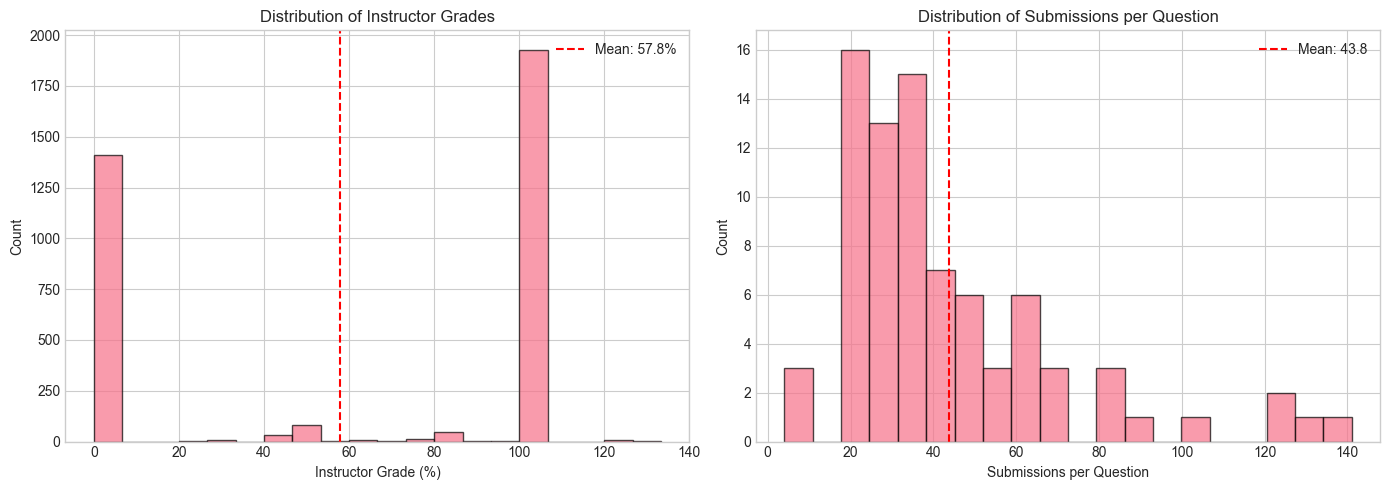

In [5]:
# Visualize grade distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of instructor grades
ax1 = axes[0]
ax1.hist(df["instructor_score_pct"], bins=20, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Instructor Grade (%)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Instructor Grades")
ax1.axvline(
    df["instructor_score_pct"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['instructor_score_pct'].mean():.1f}%",
)
ax1.legend()

# Submissions per question
ax2 = axes[1]
subs_per_q = df.groupby("question_id").size()
ax2.hist(subs_per_q, bins=20, edgecolor="black", alpha=0.7)
ax2.set_xlabel("Submissions per Question")
ax2.set_ylabel("Count")
ax2.set_title("Distribution of Submissions per Question")
ax2.axvline(
    subs_per_q.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {subs_per_q.mean():.1f}",
)
ax2.legend()

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "figures" / "data_exploration.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 4. Prompt Templates

Define the three prompt conditions following the paper's methodology:
1. **Prompt 1 - Answer Only**: Just provide acceptable answers
2. **Prompt 2 - Answer + Rubric**: Add explicit grading criteria  
3. **Prompt 3 - LLM-Generated Rubric**: Ask LLM to create rubric first

In [6]:
# Prompt Condition 1: Answer Only
PROMPT_1_ANSWER_ONLY = """You are grading a short-answer question from a university course.

**Question**: {question_text}

**Maximum Points**: {points_possible}

**Acceptable Answers** (these are the correct/expected answers):
{acceptable_answers}

**Student's Answer**: {student_answer}

Grade this student's answer. Award points based on how well the student's answer matches or conveys the same meaning as the acceptable answers.

Respond with ONLY a JSON object in this exact format:
{{"points": <number>, "reasoning": "<brief explanation>"}}

The points must be between 0 and {points_possible}."""


# Prompt Condition 2: Answer + Rubric
PROMPT_2_ANSWER_RUBRIC = """You are grading a short-answer question from a university course.

**Question**: {question_text}

**Maximum Points**: {points_possible}

**Acceptable Answers** (these are the correct/expected answers):
{acceptable_answers}

**Grading Rubric**:
- Full credit ({points_possible} points): Answer matches or is semantically equivalent to one of the acceptable answers
- Partial credit: Award proportional points if the answer is partially correct or contains the key concept but with minor errors/omissions
- Zero points: Answer is incorrect, irrelevant, or does not address the question

**Student's Answer**: {student_answer}

Grade this student's answer according to the rubric above.

Respond with ONLY a JSON object in this exact format:
{{"points": <number>, "reasoning": "<brief explanation>"}}

The points must be between 0 and {points_possible}."""


# Prompt Condition 3: First generate rubric, then grade
PROMPT_3_GENERATE_RUBRIC = """You are an expert instructor creating a grading rubric for a short-answer question.

**Question**: {question_text}

**Maximum Points**: {points_possible}

**Model Answers** (examples of correct answers):
{acceptable_answers}

Create a detailed grading rubric for this question. The rubric should specify:
1. Criteria for full credit
2. Criteria for partial credit (if applicable)
3. Criteria for zero credit

Respond with ONLY a JSON object in this exact format:
{{"rubric": "<your detailed rubric>"}}"""

PROMPT_3_GRADE_WITH_RUBRIC = """You are grading a short-answer question from a university course.

**Question**: {question_text}

**Maximum Points**: {points_possible}

**Acceptable Answers**:
{acceptable_answers}

**Grading Rubric**:
{rubric}

**Student's Answer**: {student_answer}

Grade this student's answer according to the rubric above.

Respond with ONLY a JSON object in this exact format:
{{"points": <number>, "reasoning": "<brief explanation>"}}

The points must be between 0 and {points_possible}."""


def format_acceptable_answers(answers: list[dict]) -> str:
    """Format the list of acceptable answers for the prompt."""
    return "\n".join([f"- {ans['text']}" for ans in answers])


print("Prompt templates defined successfully!")

Prompt templates defined successfully!


## 5. LLM Grading Functions

Functions to call AWS Bedrock models and parse their responses.

In [7]:
import re
import time


def format_llama3_prompt(prompt: str) -> str:
    """Format prompt for Llama 3 using proper chat template."""
    return f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a grading assistant. Grade student answers accurately and respond with valid JSON.<|eot_id|><|start_header_id|>user<|end_header_id|>

{prompt}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""


def call_bedrock_model(
    model_id: str, prompt: str, max_tokens: int = 500, temperature: float = 0.0
) -> str:
    """Call a model via AWS Bedrock and return the response text."""
    if bedrock_runtime is None:
        raise RuntimeError("Bedrock client not initialized")

    # Different models have different request formats
    if "anthropic" in model_id:
        # Claude models
        body = json.dumps(
            {
                "anthropic_version": "bedrock-2023-05-31",
                "max_tokens": max_tokens,
                "temperature": temperature,
                "messages": [{"role": "user", "content": prompt}],
            }
        )
    elif "meta.llama" in model_id:
        # Llama 3 models - need special chat format
        formatted_prompt = format_llama3_prompt(prompt)
        body = json.dumps(
            {
                "prompt": formatted_prompt,
                "max_gen_len": max_tokens,
                "temperature": temperature,
            }
        )
    elif "mistral" in model_id:
        # Mistral models
        body = json.dumps(
            {
                "prompt": f"<s>[INST] {prompt} [/INST]",
                "max_tokens": max_tokens,
                "temperature": temperature,
            }
        )
    else:
        raise ValueError(f"Unknown model format: {model_id}")

    response = bedrock_runtime.invoke_model(
        modelId=model_id,
        body=body,
        contentType="application/json",
        accept="application/json",
    )

    response_body = json.loads(response["body"].read())

    # Extract text based on model type
    if "anthropic" in model_id:
        return response_body["content"][0]["text"]
    elif "meta.llama" in model_id:
        return response_body["generation"]
    elif "mistral" in model_id:
        return response_body["outputs"][0]["text"]
    else:
        return str(response_body)


def parse_grade_response(response: str, max_points: float) -> dict:
    """Parse the LLM response to extract points and reasoning."""
    try:
        # Try to find JSON in the response
        json_match = re.search(r'\{[^{}]*"points"[^{}]*\}', response, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
            points = float(result.get("points", 0))
            # Clamp points to valid range
            points = max(0, min(points, max_points))
            return {
                "points": points,
                "reasoning": result.get("reasoning", ""),
                "raw_response": response,
                "parse_success": True,
            }
    except (json.JSONDecodeError, ValueError):
        pass

    # Fallback: try to extract a number
    numbers = re.findall(r"(\d+(?:\.\d+)?)", response)
    if numbers:
        points = float(numbers[0])
        points = max(0, min(points, max_points))
        return {
            "points": points,
            "reasoning": "",
            "raw_response": response,
            "parse_success": False,
        }

    return {
        "points": 0,
        "reasoning": "",
        "raw_response": response,
        "parse_success": False,
    }


def grade_submission(
    model_id: str,
    question_text: str,
    points_possible: float,
    acceptable_answers: list[dict],
    student_answer: str,
    prompt_condition: int,
    rubric: str = None,
) -> dict:
    """Grade a single submission using the specified model and prompt condition."""
    formatted_answers = format_acceptable_answers(acceptable_answers)

    if prompt_condition == 1:
        prompt = PROMPT_1_ANSWER_ONLY.format(
            question_text=question_text,
            points_possible=points_possible,
            acceptable_answers=formatted_answers,
            student_answer=student_answer,
        )
    elif prompt_condition == 2:
        prompt = PROMPT_2_ANSWER_RUBRIC.format(
            question_text=question_text,
            points_possible=points_possible,
            acceptable_answers=formatted_answers,
            student_answer=student_answer,
        )
    elif prompt_condition == 3:
        if rubric is None:
            raise ValueError("Rubric required for prompt condition 3")
        prompt = PROMPT_3_GRADE_WITH_RUBRIC.format(
            question_text=question_text,
            points_possible=points_possible,
            acceptable_answers=formatted_answers,
            rubric=rubric,
            student_answer=student_answer,
        )
    else:
        raise ValueError(f"Invalid prompt condition: {prompt_condition}")

    try:
        response = call_bedrock_model(model_id, prompt)
        result = parse_grade_response(response, points_possible)
        result["error"] = None
    except Exception as e:
        result = {
            "points": None,
            "reasoning": "",
            "raw_response": "",
            "parse_success": False,
            "error": str(e),
        }

    return result


def generate_rubric(
    model_id: str,
    question_text: str,
    points_possible: float,
    acceptable_answers: list[dict],
) -> str:
    """Generate a grading rubric using the LLM (for prompt condition 3)."""
    formatted_answers = format_acceptable_answers(acceptable_answers)

    prompt = PROMPT_3_GENERATE_RUBRIC.format(
        question_text=question_text,
        points_possible=points_possible,
        acceptable_answers=formatted_answers,
    )

    response = call_bedrock_model(model_id, prompt, max_tokens=1000)

    # Try to extract rubric from JSON
    try:
        json_match = re.search(r'\{[^{}]*"rubric"[^{}]*\}', response, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
            return result.get("rubric", response)
    except (json.JSONDecodeError, ValueError):
        pass

    return response


print("LLM grading functions defined successfully!")

LLM grading functions defined successfully!


## 6. Pilot Run

Test the grading pipeline on a small sample to validate prompts and estimate costs.

In [8]:
# Select a sample question for pilot testing
pilot_question_id = (
    df["question_id"].value_counts().index[0]
)  # Question with most submissions
pilot_df = df[df["question_id"] == pilot_question_id].head(5)  # Just 5 submissions

print("=== Pilot Question ===")
sample = pilot_df.iloc[0]
print(f"Question: {sample['question_text']}")
print(f"Max Points: {sample['points_possible']}")
print("Acceptable Answers:")
for ans in sample["acceptable_answers"]:
    print(f"  - {ans['text']}")
print(f"\nNumber of pilot submissions: {len(pilot_df)}")

=== Pilot Question ===
Question: The Landsat images in Figure 3 show a part of Yangzi Jiang river in China in 1989 and 2018. Is there evidence in the image that could explain the observed differences? Name the responsible feature, use 1 or 2 words.
Max Points: 3.75
Acceptable Answers:
  - Dam
  - Hydroelectricity
  - Hydroelectric dam
  - hydro dam
  - a dam
  - a hydro dam
  - a hydroelectric dam
  - the dam
  - damming
  - dams
  - electricity dam
  - hydro power

Number of pilot submissions: 5


In [9]:
# Run pilot with one model and one prompt condition
# Uncomment to run (requires AWS credentials)

PILOT_MODEL = "llama3-70b"  # Using Llama (Claude requires use-case approval)
PILOT_MODEL_ID = MODELS[PILOT_MODEL]


def run_pilot(pilot_df: pd.DataFrame, model_name: str, model_id: str):
    """Run pilot grading on a small sample."""
    results = []

    for idx, row in tqdm(
        pilot_df.iterrows(), total=len(pilot_df), desc="Pilot grading"
    ):
        # Test Prompt Condition 1 (Answer Only)
        result = grade_submission(
            model_id=model_id,
            question_text=row["question_text"],
            points_possible=row["points_possible"],
            acceptable_answers=row["acceptable_answers"],
            student_answer=row["student_answer"],
            prompt_condition=1,
        )

        results.append(
            {
                "model": model_name,
                "prompt_condition": 1,
                "question_id": row["question_id"],
                "student_answer": row["student_answer"][:50] + "...",
                "instructor_points": row["instructor_points"],
                "llm_points": result["points"],
                "reasoning": result["reasoning"][:100] if result["reasoning"] else "",
                "parse_success": result["parse_success"],
                "error": result["error"],
            }
        )

        time.sleep(0.5)  # Rate limiting

    return pd.DataFrame(results)


# Uncomment to run pilot
pilot_results = run_pilot(pilot_df, PILOT_MODEL, PILOT_MODEL_ID)
display(pilot_results)

# print("Pilot run code ready. Uncomment the lines above to execute.")

Pilot grading:   0%|          | 0/5 [00:00<?, ?it/s]

,model,prompt_condition,question_id,student_answer,instructor_points,llm_points,reasoning,parse_success,error
0,llama3-70b,1,6067826,Dam...,3.75,3.75,The student's answer 'Dam' exactly matches one...,True,None
1,llama3-70b,1,6067826,a dam...,3.75,3.75,The student's answer 'a dam' exactly matches o...,True,None
2,llama3-70b,1,6067826,Polution...,0.00,0.00,The student's answer 'Polution' does not match...,True,None
3,llama3-70b,1,6067826,flooding...,0.00,0.00,The student's answer 'flooding' does not match...,True,None
4,llama3-70b,1,6067826,Increased Waterways...,0.00,0.00,The student's answer 'Increased Waterways' doe...,True,None


## 7. Full Evaluation

Run all models across all prompt conditions on the sampled dataset.

In [10]:
def create_stratified_sample(
    df: pd.DataFrame, submissions_per_question: int = 10, seed: int = 42
) -> pd.DataFrame:
    """Create a stratified sample with equal submissions per question.

    Following the paper's methodology, we sample submissions to have a spread
    of grades representing the full range of possible scores.
    """
    np.random.seed(seed)
    sampled_dfs = []

    for question_id, group in df.groupby("question_id"):
        if len(group) <= submissions_per_question:
            sampled_dfs.append(group)
        else:
            # Try to get a spread of grades
            sorted_group = group.sort_values("instructor_score_pct")
            indices = np.linspace(
                0, len(sorted_group) - 1, submissions_per_question, dtype=int
            )
            sampled_dfs.append(sorted_group.iloc[indices])

    return pd.concat(sampled_dfs, ignore_index=True)


# =============================================================================
# QUICK RUN OPTIONS - Uncomment to speed up testing
# =============================================================================

# Option 1: Reduce submissions per question (default: 10)
SUBMISSIONS_PER_QUESTION = 5  # Halves the workload

# Option 2: Use fewer questions
sample_df = create_stratified_sample(
    df.head(1000), SUBMISSIONS_PER_QUESTION, RANDOM_SEED
)

# Option 3: Test with single model first
MODELS = {"llama3-70b": "meta.llama3-70b-instruct-v1:0"}

# =============================================================================

# Create stratified sample (default: full dataset)
sample_df = create_stratified_sample(df, SUBMISSIONS_PER_QUESTION, RANDOM_SEED)
print(
    f"Sampled dataset: {len(sample_df):,} submissions across {sample_df['question_id'].nunique()} questions"
)
print(
    f"Submissions per question: min={sample_df.groupby('question_id').size().min()}, max={sample_df.groupby('question_id').size().max()}"
)
print()

# Estimate runtime
n_calls = len(sample_df) * len(MODELS) * 3  # 3 prompt conditions
est_time = n_calls * 0.5 / 60  # ~0.5s per call
print(f"Estimated API calls: {n_calls:,}")
print(f"Estimated time (sequential): ~{est_time:.0f} minutes")
print(f"Estimated time (4 workers): ~{est_time / 4:.0f} minutes")

Sampled dataset: 404 submissions across 81 questions
Submissions per question: min=4, max=5

Estimated API calls: 1,212
Estimated time (sequential): ~10 minutes
Estimated time (4 workers): ~3 minutes


In [11]:
from concurrent.futures import ThreadPoolExecutor, as_completed


def run_full_evaluation(
    sample_df: pd.DataFrame,
    models: dict[str, str],
    prompt_conditions: list[int] = [1, 2, 3],
    delay: float = 0.2,  # Reduced from 0.5
    max_workers: int = 4,  # Parallel API calls
) -> pd.DataFrame:
    """Run full evaluation across all models and prompt conditions.

    Speed optimizations:
    - Reduced delay between calls (0.2s instead of 0.5s)
    - Parallel processing with ThreadPoolExecutor
    - Progress bars for visibility
    """
    all_results = []
    rubrics = {}  # (model_name, question_id) -> rubric

    # Pre-generate rubrics for prompt condition 3 (one per question per model)
    if 3 in prompt_conditions:
        print("Generating rubrics for prompt condition 3...")
        for model_name, model_id in models.items():
            print(f"  {model_name}...")
            for question_id in tqdm(
                sample_df["question_id"].unique(),
                desc=f"Rubrics for {model_name}",
                leave=False,
            ):
                q_row = sample_df[sample_df["question_id"] == question_id].iloc[0]
                try:
                    rubric = generate_rubric(
                        model_id=model_id,
                        question_text=q_row["question_text"],
                        points_possible=q_row["points_possible"],
                        acceptable_answers=q_row["acceptable_answers"],
                    )
                    rubrics[(model_name, question_id)] = rubric
                    time.sleep(delay)
                except Exception:
                    rubrics[(model_name, question_id)] = "Grade based on correctness."

    def grade_single(args):
        """Grade a single submission (for parallel execution)."""
        model_name, model_id, row, condition, rubric = args
        try:
            result = grade_submission(
                model_id=model_id,
                question_text=row["question_text"],
                points_possible=row["points_possible"],
                acceptable_answers=row["acceptable_answers"],
                student_answer=row["student_answer"],
                prompt_condition=condition,
                rubric=rubric,
            )
        except Exception as e:
            result = {
                "points": None,
                "reasoning": "",
                "parse_success": False,
                "error": str(e),
            }

        llm_score_pct = (
            result["points"] / row["points_possible"] * 100
            if result["points"] is not None and row["points_possible"] > 0
            else None
        )

        return {
            "model": model_name,
            "prompt_condition": condition,
            "question_id": row["question_id"],
            "offering": row["offering"],
            "instructor_points": row["instructor_points"],
            "instructor_score_pct": row["instructor_score_pct"],
            "llm_points": result["points"],
            "llm_score_pct": llm_score_pct,
            "parse_success": result["parse_success"],
            "error": result.get("error"),
        }

    # Build task list
    tasks = []
    for model_name, model_id in models.items():
        for _, row in sample_df.iterrows():
            for condition in prompt_conditions:
                rubric = (
                    rubrics.get((model_name, row["question_id"]))
                    if condition == 3
                    else None
                )
                tasks.append((model_name, model_id, row, condition, rubric))

    print(f"\nGrading {len(tasks)} submissions with {max_workers} parallel workers...")

    # Process in parallel with rate limiting
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for task in tasks:
            futures.append(executor.submit(grade_single, task))
            time.sleep(delay / max_workers)  # Stagger submissions

        for future in tqdm(as_completed(futures), total=len(futures), desc="Grading"):
            try:
                all_results.append(future.result())
            except Exception as e:
                print(f"Task failed: {e}")

    return pd.DataFrame(all_results)


# Uncomment to run full evaluation
results_df = run_full_evaluation(sample_df, MODELS, prompt_conditions=[1, 2])
results_df.to_csv(RESULTS_DIR / "grading_results.csv", index=False)
print(f"Results saved to {RESULTS_DIR / 'grading_results.csv'}")

print("Full evaluation code ready. Uncomment the lines above to execute.")
print()
print("Speed tips:")
print("- Use fewer models: MODELS = {'llama3-70b': MODELS['llama3-70b']}")
print("- Use fewer conditions: prompt_conditions=[1]")
print("- Reduce sample: SUBMISSIONS_PER_QUESTION = 5")
print("- Increase workers (risk rate limits): max_workers=8")


Grading 808 submissions with 4 parallel workers...


Grading:   0%|          | 0/808 [00:00<?, ?it/s]

Results saved to results/grading_results.csv
Full evaluation code ready. Uncomment the lines above to execute.

Speed tips:
- Use fewer models: MODELS = {'llama3-70b': MODELS['llama3-70b']}
- Use fewer conditions: prompt_conditions=[1]
- Reduce sample: SUBMISSIONS_PER_QUESTION = 5
- Increase workers (risk rate limits): max_workers=8


In [12]:
# Load existing results if available (for analysis without re-running)
results_file = RESULTS_DIR / "grading_results.csv"
if results_file.exists():
    results_df = pd.read_csv(results_file)
    print(f"Loaded existing results: {len(results_df):,} rows")
    print(f"Models: {results_df['model'].unique().tolist()}")
    print(f"Prompt conditions: {results_df['prompt_condition'].unique().tolist()}")
else:
    print("No existing results found. Run the full evaluation above first.")
    # Create dummy results for demonstration
    results_df = None

Loaded existing results: 808 rows
Models: ['llama3-70b']
Prompt conditions: [1, 2]


## 8. Statistical Analysis

Replicate the paper's statistical methodology:
- Normality tests (Shapiro-Wilk)
- Variance tests (Levene's)
- Friedman test for comparing graders
- Conover's post-hoc with Bonferroni correction
- ICC (Intraclass Correlation Coefficient)
- RMS differences
- Bootstrap confidence intervals

In [13]:
def check_normality(data: np.ndarray, name: str = "data") -> dict:
    """Test normality using Shapiro-Wilk test."""
    # Shapiro-Wilk has a sample size limit
    sample = data[:5000] if len(data) > 5000 else data
    stat, p_value = shapiro(sample)
    return {
        "name": name,
        "statistic": stat,
        "p_value": p_value,
        "is_normal": p_value > 0.05,
    }


def check_homogeneity(*groups, names: list[str] = None) -> dict:
    """Test homogeneity of variances using Levene's test."""
    stat, p_value = levene(*groups)
    return {"statistic": stat, "p_value": p_value, "equal_variances": p_value > 0.05}


def calculate_rms_difference(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculate Root Mean Square difference."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calculate_icc(ratings_df: pd.DataFrame) -> dict:
    """
    Calculate Intraclass Correlation Coefficient (ICC).

    Uses ICC(2,1) - two-way random effects, single rater/measurement.
    """
    try:
        icc_result = pg.intraclass_corr(
            data=ratings_df, targets="submission_id", raters="rater", ratings="score"
        )
        # Get ICC(2,1) - Two-way random, single measures
        icc_row = icc_result[icc_result["Type"] == "ICC2"]
        if len(icc_row) > 0:
            return {
                "icc": icc_row["ICC"].values[0],
                "ci_lower": icc_row["CI95%"].values[0][0],
                "ci_upper": icc_row["CI95%"].values[0][1],
                "p_value": icc_row["pval"].values[0],
            }
    except Exception as e:
        print(f"ICC calculation error: {e}")

    return {"icc": None, "ci_lower": None, "ci_upper": None, "p_value": None}


def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    n_iterations: int = 10000,
    ci: float = 0.95,
    seed: int = 42,
) -> dict:
    """Calculate bootstrap confidence interval for mean difference."""
    np.random.seed(seed)
    differences = y_pred - y_true
    n = len(differences)

    bootstrap_means = []
    for _ in range(n_iterations):
        sample = np.random.choice(differences, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))

    bootstrap_means = np.array(bootstrap_means)
    alpha = 1 - ci
    ci_lower = np.percentile(bootstrap_means, alpha / 2 * 100)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha / 2) * 100)

    return {
        "mean_diff": np.mean(differences),
        "std_diff": np.std(differences),
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "n_iterations": n_iterations,
    }


def run_friedman_test(groups: list[np.ndarray]) -> dict:
    """Run Friedman test for comparing multiple related samples."""
    stat, p_value = friedmanchisquare(*groups)
    return {"statistic": stat, "p_value": p_value, "significant": p_value < 0.05}


def conover_posthoc(data_wide: pd.DataFrame) -> pd.DataFrame:
    """
    Perform Conover's post-hoc test with Bonferroni correction.

    data_wide: DataFrame with columns as different graders/conditions
    """
    # Use pingouin's pairwise tests
    # First, melt to long format
    data_long = data_wide.melt(var_name="grader", value_name="score")
    data_long["subject"] = np.tile(np.arange(len(data_wide)), len(data_wide.columns))

    # Pairwise Wilcoxon tests with Bonferroni correction
    posthoc = pg.pairwise_tests(
        data=data_long,
        dv="score",
        within="grader",
        subject="subject",
        parametric=False,
        padjust="bonf",
    )

    return posthoc


print("Statistical analysis functions defined successfully!")

Statistical analysis functions defined successfully!


In [14]:
def run_statistical_analysis(results_df: pd.DataFrame) -> dict:
    """Run comprehensive statistical analysis on grading results."""
    analysis = {}

    # Filter out failed parses
    valid_results = results_df[results_df["llm_score_pct"].notna()].copy()

    if len(valid_results) == 0:
        print("No valid results to analyze")
        return analysis

    print("=" * 60)
    print("STATISTICAL ANALYSIS")
    print("=" * 60)

    # 1. Normality Tests
    print("\n1. NORMALITY TESTS (Shapiro-Wilk)")
    print("-" * 40)
    instructor_scores = valid_results["instructor_score_pct"].values
    norm_instructor = check_normality(instructor_scores, "Instructor")
    print(
        f"Instructor grades: W={norm_instructor['statistic']:.4f}, p={norm_instructor['p_value']:.4f}"
    )
    print(f"  Normal distribution: {'Yes' if norm_instructor['is_normal'] else 'No'}")

    for model in valid_results["model"].unique():
        for condition in valid_results["prompt_condition"].unique():
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            llm_scores = valid_results.loc[mask, "llm_score_pct"].values
            if len(llm_scores) > 3:
                norm_llm = check_normality(llm_scores, f"{model}_P{condition}")
                print(
                    f"{model} (P{condition}): W={norm_llm['statistic']:.4f}, p={norm_llm['p_value']:.4f}"
                )

    analysis["normality"] = norm_instructor

    # 2. Summary Statistics by Model and Prompt Condition
    print("\n2. SUMMARY STATISTICS")
    print("-" * 40)

    summary_stats = (
        valid_results.groupby(["model", "prompt_condition"])
        .agg(
            {"instructor_score_pct": "mean", "llm_score_pct": ["mean", "std", "count"]}
        )
        .round(2)
    )
    summary_stats.columns = ["Instructor Mean", "LLM Mean", "LLM Std", "N"]
    print(summary_stats)
    analysis["summary_stats"] = summary_stats

    # 3. RMS Differences
    print("\n3. RMS DIFFERENCES (Instructor vs LLM)")
    print("-" * 40)

    rms_results = []
    for model in valid_results["model"].unique():
        for condition in valid_results["prompt_condition"].unique():
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            subset = valid_results[mask]
            if len(subset) > 0:
                rms = calculate_rms_difference(
                    subset["instructor_score_pct"].values,
                    subset["llm_score_pct"].values,
                )
                rms_results.append(
                    {"Model": model, "Prompt": f"P{condition}", "RMS": round(rms, 2)}
                )
                print(f"{model} (P{condition}): RMS = {rms:.2f}")

    analysis["rms"] = pd.DataFrame(rms_results)

    # 4. Bootstrap Confidence Intervals
    print("\n4. BOOTSTRAP CONFIDENCE INTERVALS (95%)")
    print("-" * 40)

    bootstrap_results = []
    for model in valid_results["model"].unique():
        for condition in valid_results["prompt_condition"].unique():
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            subset = valid_results[mask]
            if len(subset) > 10:
                bs = bootstrap_ci(
                    subset["instructor_score_pct"].values,
                    subset["llm_score_pct"].values,
                )
                bootstrap_results.append(
                    {
                        "Model": model,
                        "Prompt": f"P{condition}",
                        "Mean Diff": round(bs["mean_diff"], 2),
                        "95% CI": f"[{bs['ci_lower']:.2f}, {bs['ci_upper']:.2f}]",
                    }
                )
                print(
                    f"{model} (P{condition}): Mean diff = {bs['mean_diff']:.2f}, "
                    f"95% CI = [{bs['ci_lower']:.2f}, {bs['ci_upper']:.2f}]"
                )

    analysis["bootstrap"] = pd.DataFrame(bootstrap_results)

    return analysis


# Run analysis if results exist
if results_df is not None:
    analysis_results = run_statistical_analysis(results_df)
else:
    print("Run the full evaluation first to generate results for analysis.")

STATISTICAL ANALYSIS

1. NORMALITY TESTS (Shapiro-Wilk)
----------------------------------------
Instructor grades: W=0.6779, p=0.0000
  Normal distribution: No
llama3-70b (P1): W=0.6914, p=0.0000
llama3-70b (P2): W=0.6817, p=0.0000

2. SUMMARY STATISTICS
----------------------------------------
                             Instructor Mean  LLM Mean  LLM Std    N
model      prompt_condition                                         
llama3-70b 1                           54.32     50.95    47.75  404
           2                           54.32     57.56    47.24  404

3. RMS DIFFERENCES (Instructor vs LLM)
----------------------------------------
llama3-70b (P1): RMS = 32.03
llama3-70b (P2): RMS = 34.39

4. BOOTSTRAP CONFIDENCE INTERVALS (95%)
----------------------------------------
llama3-70b (P1): Mean diff = -3.37, 95% CI = [-6.52, -0.31]
llama3-70b (P2): Mean diff = 3.24, 95% CI = [-0.04, 6.60]


## 9. Visualizations

Create plots following the paper's figures:
- Grade distribution histograms
- Instructor vs LLM scatter plots  
- Agreement heatmaps by model/condition

Generating visualizations...


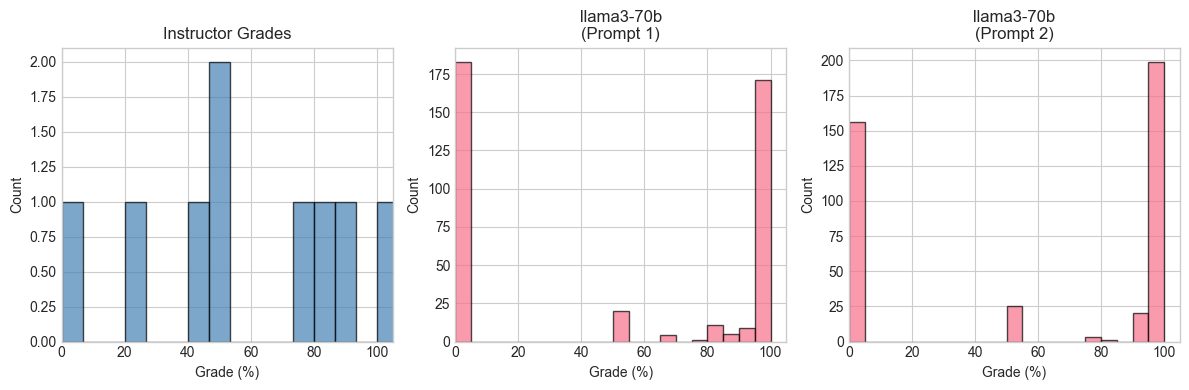

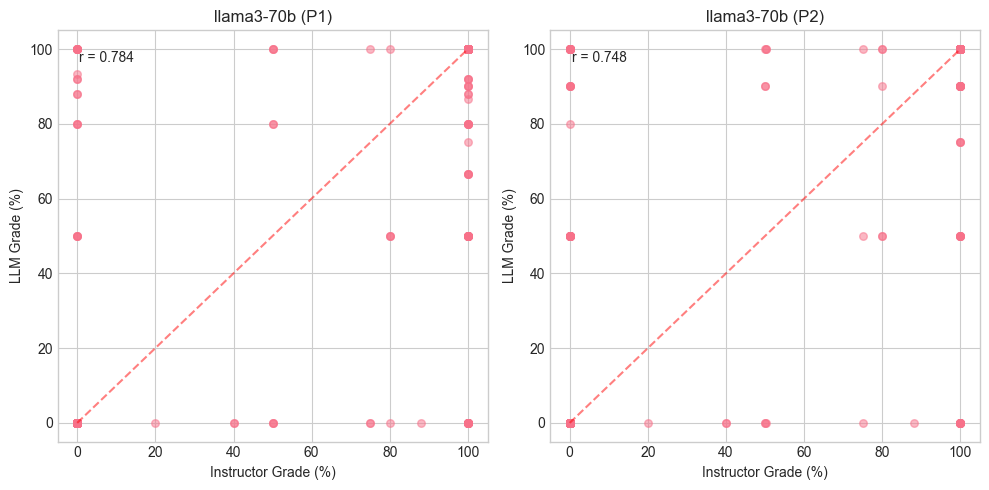

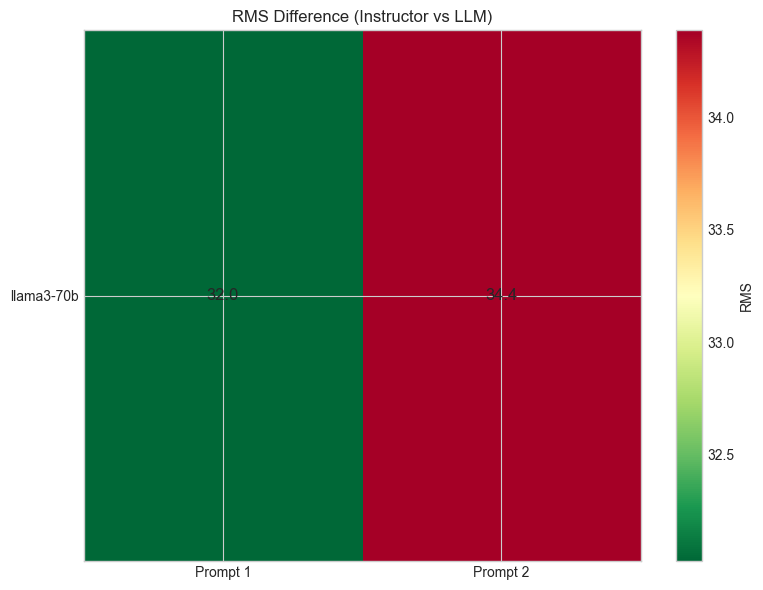

In [15]:
def plot_grade_distributions(results_df: pd.DataFrame, save_path: Path = None):
    """Plot histograms of grades from instructor and LLMs (like Figure 1 in paper)."""
    valid_results = results_df[results_df["llm_score_pct"].notna()]

    models = valid_results["model"].unique()
    conditions = sorted(valid_results["prompt_condition"].unique())

    n_plots = 1 + len(models) * len(
        conditions
    )  # Instructor + each model/condition combo
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    # Instructor grades
    ax = axes[0]
    ax.hist(
        valid_results["instructor_score_pct"].drop_duplicates(),
        bins=20,
        edgecolor="black",
        alpha=0.7,
        color="steelblue",
    )
    ax.set_xlabel("Grade (%)")
    ax.set_ylabel("Count")
    ax.set_title("Instructor Grades")
    ax.set_xlim(0, 105)

    # LLM grades by model and condition
    plot_idx = 1
    for model in models:
        for condition in conditions:
            if plot_idx >= len(axes):
                break
            ax = axes[plot_idx]
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            data = valid_results.loc[mask, "llm_score_pct"]
            ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
            ax.set_xlabel("Grade (%)")
            ax.set_ylabel("Count")
            ax.set_title(f"{model}\n(Prompt {condition})")
            ax.set_xlim(0, 105)
            plot_idx += 1

    # Hide unused axes
    for ax in axes[plot_idx:]:
        ax.set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_instructor_vs_llm_scatter(results_df: pd.DataFrame, save_path: Path = None):
    """Scatter plot of instructor vs LLM grades (like Figure 2 in paper)."""
    valid_results = results_df[results_df["llm_score_pct"].notna()]

    models = valid_results["model"].unique()
    conditions = sorted(valid_results["prompt_condition"].unique())

    n_models = len(models)
    n_conditions = len(conditions)

    fig, axes = plt.subplots(
        n_models, n_conditions, figsize=(5 * n_conditions, 5 * n_models)
    )
    if n_models == 1 and n_conditions == 1:
        axes = np.array([[axes]])
    elif n_models == 1:
        axes = axes.reshape(1, -1)
    elif n_conditions == 1:
        axes = axes.reshape(-1, 1)

    for i, model in enumerate(models):
        for j, condition in enumerate(conditions):
            ax = axes[i, j]
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            data = valid_results[mask]

            ax.scatter(
                data["instructor_score_pct"], data["llm_score_pct"], alpha=0.5, s=30
            )

            # Perfect agreement line
            ax.plot([0, 100], [0, 100], "r--", alpha=0.5, label="Perfect agreement")

            # Correlation
            if len(data) > 2:
                corr = data["instructor_score_pct"].corr(data["llm_score_pct"])
                ax.text(
                    0.05,
                    0.95,
                    f"r = {corr:.3f}",
                    transform=ax.transAxes,
                    fontsize=10,
                    verticalalignment="top",
                )

            ax.set_xlabel("Instructor Grade (%)")
            ax.set_ylabel("LLM Grade (%)")
            ax.set_title(f"{model} (P{condition})")
            ax.set_xlim(-5, 105)
            ax.set_ylim(-5, 105)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_rms_heatmap(results_df: pd.DataFrame, save_path: Path = None):
    """Heatmap of RMS differences by model and prompt condition."""
    valid_results = results_df[results_df["llm_score_pct"].notna()]

    models = valid_results["model"].unique()
    conditions = sorted(valid_results["prompt_condition"].unique())

    rms_matrix = np.zeros((len(models), len(conditions)))

    for i, model in enumerate(models):
        for j, condition in enumerate(conditions):
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            subset = valid_results[mask]
            if len(subset) > 0:
                rms_matrix[i, j] = calculate_rms_difference(
                    subset["instructor_score_pct"].values,
                    subset["llm_score_pct"].values,
                )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(rms_matrix, cmap="RdYlGn_r", aspect="auto")

    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels([f"Prompt {c}" for c in conditions])
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models)

    # Add text annotations
    for i in range(len(models)):
        for j in range(len(conditions)):
            ax.text(
                j, i, f"{rms_matrix[i, j]:.1f}", ha="center", va="center", fontsize=12
            )

    ax.set_title("RMS Difference (Instructor vs LLM)")
    plt.colorbar(im, ax=ax, label="RMS")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Run visualizations if results exist
if results_df is not None:
    print("Generating visualizations...")
    plot_grade_distributions(
        results_df, RESULTS_DIR / "figures" / "grade_distributions.png"
    )
    plot_instructor_vs_llm_scatter(
        results_df, RESULTS_DIR / "figures" / "scatter_plots.png"
    )
    plot_rms_heatmap(results_df, RESULTS_DIR / "figures" / "rms_heatmap.png")
else:
    print("Run the full evaluation first to generate visualizations.")

## 10. Results Summary

Generate summary tables comparing models and prompt conditions.

In [16]:
def generate_summary_tables(results_df: pd.DataFrame) -> dict:
    """Generate summary tables for the evaluation results."""
    valid_results = results_df[results_df["llm_score_pct"].notna()]

    if len(valid_results) == 0:
        print("No valid results to summarize")
        return {}

    tables = {}

    # Table 1: Overall Statistics
    print("=" * 70)
    print("TABLE 1: OVERALL STATISTICS BY MODEL AND PROMPT CONDITION")
    print("=" * 70)

    overall_stats = []
    instructor_mean = valid_results["instructor_score_pct"].mean()

    for model in valid_results["model"].unique():
        for condition in sorted(valid_results["prompt_condition"].unique()):
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            subset = valid_results[mask]

            if len(subset) > 0:
                llm_mean = subset["llm_score_pct"].mean()
                llm_std = subset["llm_score_pct"].std()
                rms = calculate_rms_difference(
                    subset["instructor_score_pct"].values,
                    subset["llm_score_pct"].values,
                )
                corr = subset["instructor_score_pct"].corr(subset["llm_score_pct"])

                overall_stats.append(
                    {
                        "Model": model,
                        "Prompt": f"P{condition}",
                        "N": len(subset),
                        "Instructor Mean": round(instructor_mean, 1),
                        "LLM Mean": round(llm_mean, 1),
                        "LLM Std": round(llm_std, 1),
                        "RMS": round(rms, 1),
                        "Correlation": round(corr, 3),
                    }
                )

    table1 = pd.DataFrame(overall_stats)
    print(table1.to_string(index=False))
    tables["overall_stats"] = table1

    # Table 2: Accuracy Breakdown
    print("\n" + "=" * 70)
    print("TABLE 2: GRADING ACCURACY BREAKDOWN")
    print("=" * 70)

    accuracy_stats = []
    for model in valid_results["model"].unique():
        for condition in sorted(valid_results["prompt_condition"].unique()):
            mask = (valid_results["model"] == model) & (
                valid_results["prompt_condition"] == condition
            )
            subset = valid_results[mask]

            if len(subset) > 0:
                # Calculate various accuracy metrics
                diff = subset["llm_score_pct"] - subset["instructor_score_pct"]

                exact_match = (diff.abs() < 1).mean() * 100  # Within 1%
                within_5 = (diff.abs() <= 5).mean() * 100
                within_10 = (diff.abs() <= 10).mean() * 100

                accuracy_stats.append(
                    {
                        "Model": model,
                        "Prompt": f"P{condition}",
                        "Exact Match (±1%)": round(exact_match, 1),
                        "Within ±5%": round(within_5, 1),
                        "Within ±10%": round(within_10, 1),
                        "Mean Bias": round(diff.mean(), 1),
                    }
                )

    table2 = pd.DataFrame(accuracy_stats)
    print(table2.to_string(index=False))
    tables["accuracy"] = table2

    # Table 3: Best Model/Condition Summary
    print("\n" + "=" * 70)
    print("TABLE 3: RANKING BY RMS (LOWER IS BETTER)")
    print("=" * 70)

    if len(overall_stats) > 0:
        ranking = table1.sort_values("RMS")[["Model", "Prompt", "RMS", "Correlation"]]
        print(ranking.to_string(index=False))
        tables["ranking"] = ranking

    return tables


# Generate summary if results exist
if results_df is not None:
    summary_tables = generate_summary_tables(results_df)
else:
    print("Run the full evaluation first to generate summary tables.")

TABLE 1: OVERALL STATISTICS BY MODEL AND PROMPT CONDITION
     Model Prompt   N  Instructor Mean  LLM Mean  LLM Std  RMS  Correlation
llama3-70b     P1 404             54.3      50.9     47.8 32.0        0.784
llama3-70b     P2 404             54.3      57.6     47.2 34.4        0.748

TABLE 2: GRADING ACCURACY BREAKDOWN
     Model Prompt  Exact Match (±1%)  Within ±5%  Within ±10%  Mean Bias
llama3-70b     P1               76.5        76.5         78.0       -3.4
llama3-70b     P2               75.0        75.0         78.2        3.2

TABLE 3: RANKING BY RMS (LOWER IS BETTER)
     Model Prompt  RMS  Correlation
llama3-70b     P1 32.0        0.784
llama3-70b     P2 34.4        0.748


## Conclusions & Next Steps

### Key Findings
(To be filled after running the evaluation)

### Comparison with Paper
The paper (Impey et al., 2025) found:
- LLM + answer + rubric achieved p=1.000 (no significant difference from instructor)
- ICC of 0.92 indicating excellent reliability
- LLMs tend to be more lenient than instructors

### Next Steps
1. Run full evaluation with all models
2. Compare results across prompt conditions
3. Analyze question-level performance
4. Consider prompt optimization based on findings

In [17]:
# Export all results
def export_results(results_df: pd.DataFrame, summary_tables: dict, results_dir: Path):
    """Export all results to files."""
    if results_df is not None:
        results_df.to_csv(results_dir / "grading_results.csv", index=False)
        print(f"Saved: {results_dir / 'grading_results.csv'}")

    for name, table in summary_tables.items():
        filepath = results_dir / f"table_{name}.csv"
        table.to_csv(filepath, index=False)
        print(f"Saved: {filepath}")

    print(f"\nAll results exported to: {results_dir}")


# Uncomment to export
# if results_df is not None:
#     export_results(results_df, summary_tables, RESULTS_DIR)

print("Notebook complete! Ready to run evaluation.")

Notebook complete! Ready to run evaluation.
